In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score

In [3]:
class MeraLR:
    
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        
        
        m, n = X.shape
        self.coef_ = np.zeros((n, 1))
        self.intercept_ = 0.0
        
        
        for _ in range(self.epochs):
            y_pred = np.dot(X, self.coef_) + self.intercept_
            
            
            dw = (1/m) * np.dot(X.T, (y_pred - y))
            db = (1/m) * np.sum(y_pred - y)
            
            
            self.coef_ -= self.lr * dw
            self.intercept_ -= self.lr * db

    def predict(self, X):
        return np.dot(np.array(X), self.coef_) + self.intercept_

=== Raw Dataset Structure ===
Total Observations: 10000
Total Base Columns: 14


/tmp/ipykernel_59152/754352527.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine failure', data=df, ax=axes[0], palette='Set2')


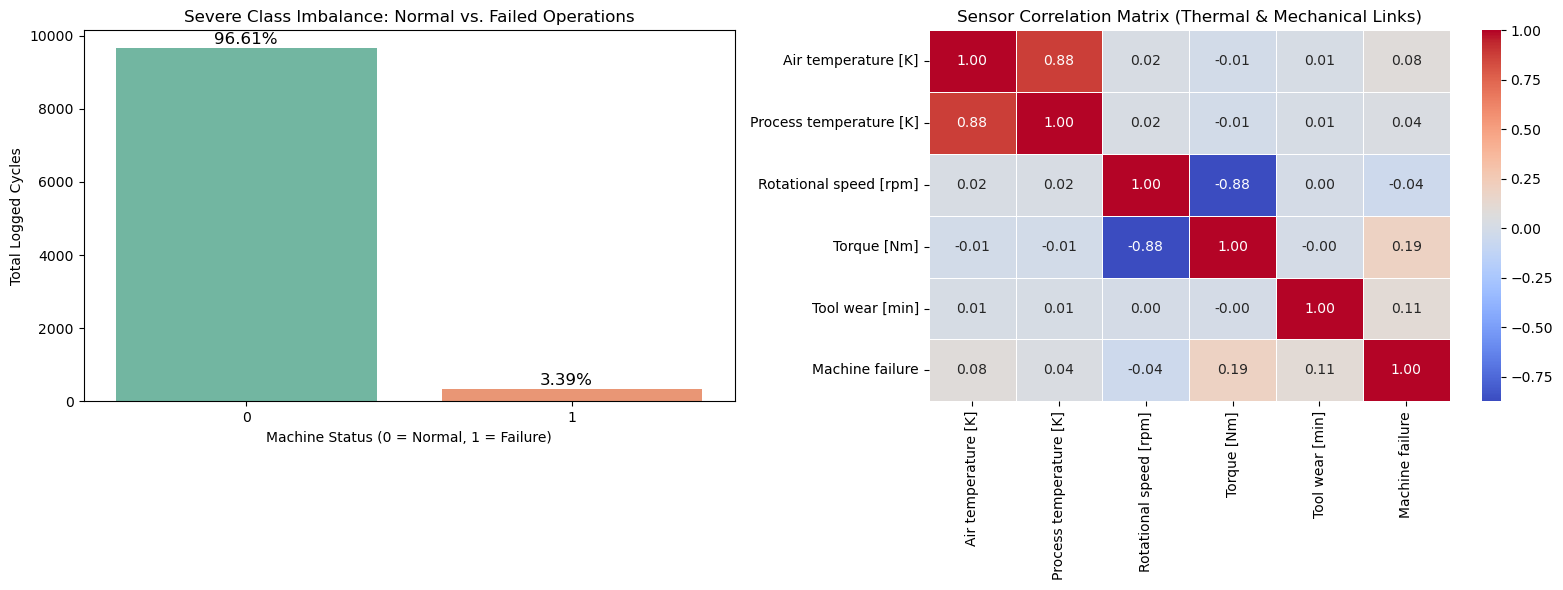

In [5]:

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
df = pd.read_csv(url)

print("=== Raw Dataset Structure ===")
print(f"Total Observations: {df.shape[0]}\nTotal Base Columns: {df.shape[1]}")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.countplot(x='Machine failure', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Severe Class Imbalance: Normal vs. Failed Operations')
axes[0].set_xlabel('Machine Status (0 = Normal, 1 = Failure)')
axes[0].set_ylabel('Total Logged Cycles')
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / len(df):.2f}%'
    axes[0].annotate(percentage, (p.get_x() + 0.3, p.get_height() + 100), fontsize=12)


corr_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
sns.heatmap(df[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title('Sensor Correlation Matrix (Thermal & Mechanical Links)')
plt.tight_layout()
plt.show()

In [6]:
df_engineered = df.copy()


df_engineered = df_engineered.sort_values(by='UDI').reset_index(drop=True)

# Feature engineering structural degradation trends over time
df_engineered['Temp_Diff'] = df_engineered['Process temperature [K]'] - df_engineered['Air temperature [K]']
df_engineered['Power_Est'] = df_engineered['Rotational speed [rpm]'] * df_engineered['Torque [Nm]']
df_engineered['Rolling_Torque_Mean'] = df_engineered['Torque [Nm]'].rolling(window=5, min_periods=1).mean()
df_engineered['Rolling_Speed_Std'] = df_engineered['Rotational speed [rpm]'].rolling(window=5, min_periods=1).std().fillna(0)

In [7]:

X = df_engineered.drop(columns=['UDI', 'Product ID', 'Type', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df_engineered['Machine failure']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)


print("\n[Execution] Training Baseline Standalone Random Forest Model...")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]


print("[Execution] Training Parallel Soft Voting Ensemble Panel...")
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

ensemble_clf = VotingClassifier(
    estimators=[('rf', rf_model), ('gb', gb_model), ('lr', lr_model)],
    voting='soft'
)
ensemble_clf.fit(X_train_scaled, y_train)

y_pred_ens = ensemble_clf.predict(X_test_scaled)
y_pred_proba_ens = ensemble_clf.predict_proba(X_test_scaled)[:, 1]


[Execution] Training Baseline Standalone Random Forest Model...
[Execution] Training Parallel Soft Voting Ensemble Panel...



     BENCHMARK CLASSIFICATION METRICS      

>>> MODEL A: STANDALONE RANDOM FOREST PERFORMANCE:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.92      0.65      0.76        68

    accuracy                           0.99      2000
   macro avg       0.95      0.82      0.88      2000
weighted avg       0.99      0.99      0.98      2000


>>> MODEL B: MULTI-MODEL VOTING ENSEMBLE PERFORMANCE:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.89      0.79      0.84        68

    accuracy                           0.99      2000
   macro avg       0.94      0.90      0.92      2000
weighted avg       0.99      0.99      0.99      2000



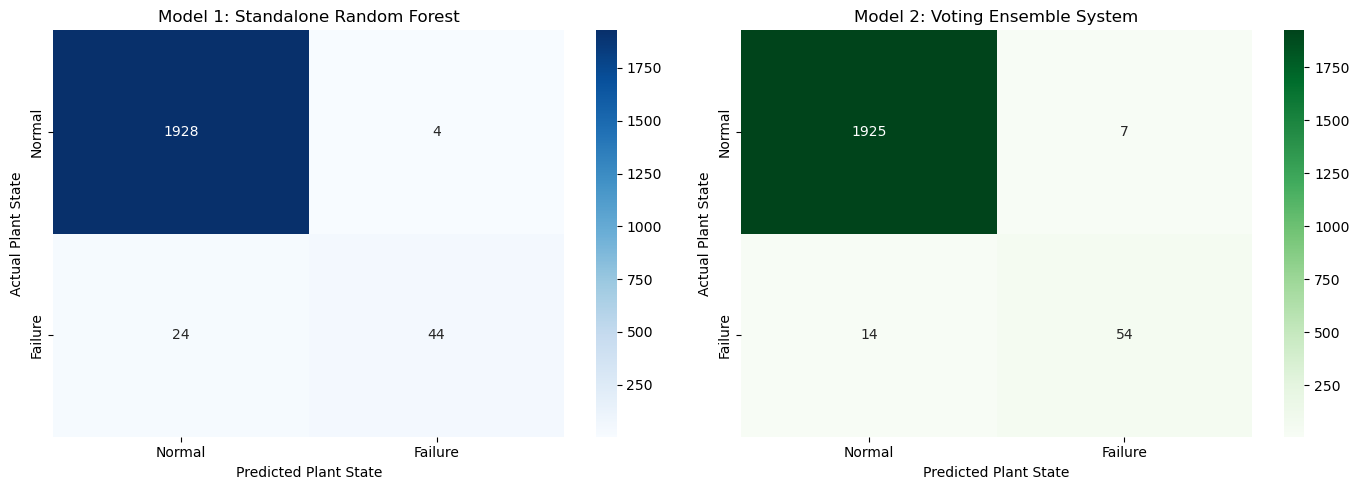

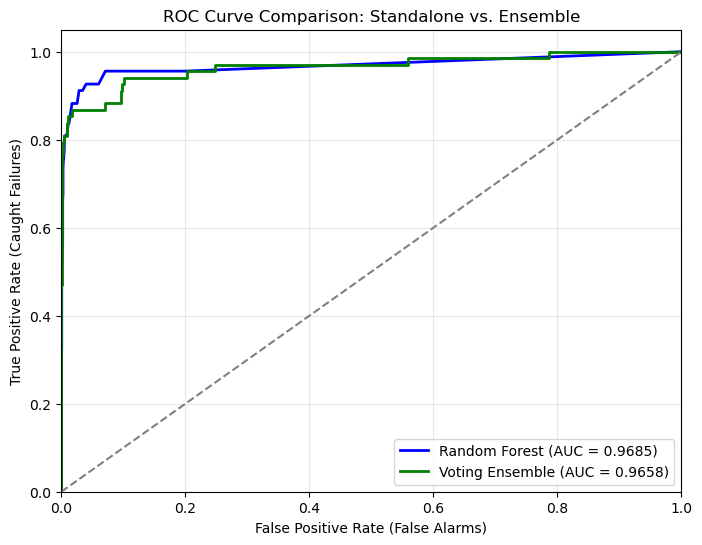


----------------------------------------
Standalone Random Forest Operational Summary:
• Plant Safety Protection (Recall): 64.71% of all actual failures caught.
• Maintenance Precision: 91.67% of alerts were real anomalies.
• False Alarm Rate (FPR): 0.21% chance of calling unneeded maintenance.

Voting Ensemble Operational Summary:
• Plant Safety Protection (Recall): 79.41% of all actual failures caught.
• Maintenance Precision: 88.52% of alerts were real anomalies.
• False Alarm Rate (FPR): 0.36% chance of calling unneeded maintenance.
----------------------------------------


In [8]:
print("\n" + "="*40)
print("     BENCHMARK CLASSIFICATION METRICS      ")
print("="*40)
print("\n>>> MODEL A: STANDALONE RANDOM FOREST PERFORMANCE:")
print(classification_report(y_test, y_pred_rf))

print("\n>>> MODEL B: MULTI-MODEL VOTING ENSEMBLE PERFORMANCE:")
print(classification_report(y_test, y_pred_ens))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'], ax=axes[0])
axes[0].set_title('Model 1: Standalone Random Forest')
axes[0].set_ylabel('Actual Plant State')
axes[0].set_xlabel('Predicted Plant State')

cm_ens = confusion_matrix(y_test, y_pred_ens)
sns.heatmap(cm_ens, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Normal', 'Failure'], yticklabels=['Normal', 'Failure'], ax=axes[1])
axes[1].set_title('Model 2: Voting Ensemble System')
axes[1].set_ylabel('Actual Plant State')
axes[1].set_xlabel('Predicted Plant State')
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
fpr_ens, tpr_ens, _ = roc_curve(y_test, y_pred_proba_ens)

plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {auc(fpr_rf, tpr_rf):.4f})')
plt.plot(fpr_ens, tpr_ens, color='green', lw=2, label=f'Voting Ensemble (AUC = {auc(fpr_ens, tpr_ens):.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Caught Failures)')
plt.title('ROC Curve Comparison: Standalone vs. Ensemble')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
fpr_rf_metric = cm_rf[0][1] / (cm_rf[0][0] + cm_rf[0][1])

print("\n" + "-"*40)
print("Standalone Random Forest Operational Summary:")
print(f"• Plant Safety Protection (Recall): {recall_rf*100:.2f}% of all actual failures caught.")
print(f"• Maintenance Precision: {precision_rf*100:.2f}% of alerts were real anomalies.")
print(f"• False Alarm Rate (FPR): {fpr_rf_metric*100:.2f}% chance of calling unneeded maintenance.")


precision_ens = precision_score(y_test, y_pred_ens)
recall_ens = recall_score(y_test, y_pred_ens)
fpr_ens_metric = cm_ens[0][1] / (cm_ens[0][0] + cm_ens[0][1])

print("\nVoting Ensemble Operational Summary:")
print(f"• Plant Safety Protection (Recall): {recall_ens*100:.2f}% of all actual failures caught.")
print(f"• Maintenance Precision: {precision_ens*100:.2f}% of alerts were real anomalies.")
print(f"• False Alarm Rate (FPR): {fpr_ens_metric*100:.2f}% chance of calling unneeded maintenance.")
print("-"*40)

/tmp/ipykernel_59152/1699656707.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=forest_importances.head(8), palette='viridis')


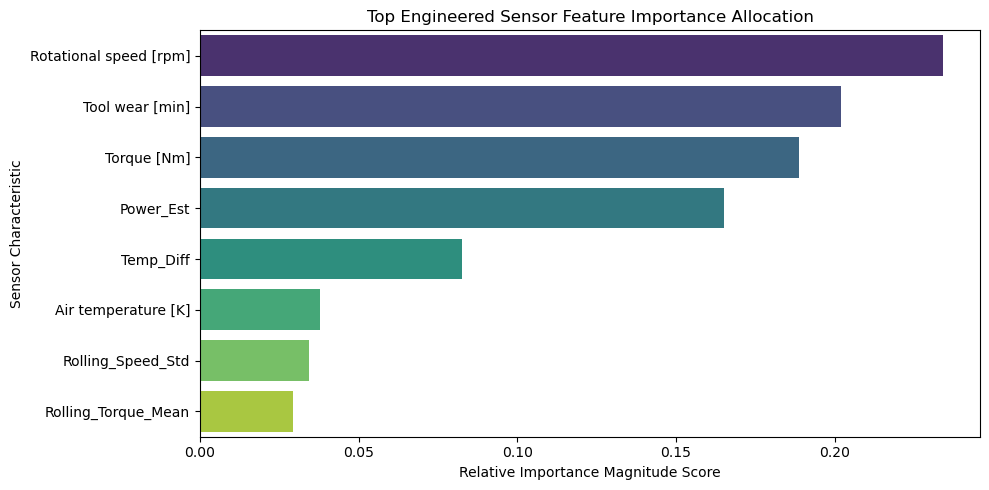

In [9]:

importances = rf_model.feature_importances_
forest_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=forest_importances.head(8), palette='viridis')
plt.title('Top Engineered Sensor Feature Importance Allocation')
plt.xlabel('Relative Importance Magnitude Score')
plt.ylabel('Sensor Characteristic')
plt.tight_layout()
plt.show()